# 딥러닝실습 팀 프로젝트 — Video Modality

팀: 5조 | 담당: 24011917 이지현  
목표: CMU-MOSI 감성 분석 | 모달리티: 영상(이미지)  
아키텍처: **MTCNN** → EfficientNet-B0 / ResNet-18 → **256-dim feature** (멀티모달 fusion용)

# Part 1. 셋업

In [1]:
import os, random, pickle, time, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import (
    efficientnet_b0, EfficientNet_B0_Weights,
    resnet18, ResNet18_Weights,
)
from facenet_pytorch import MTCNN

#plt.rcParams['font.family'] = 'Malgun Gothic'
#plt.rcParams['axes.unicode_minus'] = False

import torch.multiprocessing as mp
mp.set_start_method('spawn', force=True)

print('torch:', torch.__version__)
print('CUDA :', torch.cuda.is_available())

/data/news_group/newsgroup/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


torch: 2.2.2+cu121
CUDA : True


In [2]:
SEED        = 42
IMG_SIZE    = 224
BATCH_SIZE  = 64
FEATURE_DIM = 256  # 멀티모달 fusion용 출력 차원

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ROOT_PATH    = r'/data/news_group/newsgroup/code/AI/labeling/train/emotion/data'
VIDEO_FOLDER = os.path.join(ROOT_PATH, 'Video', 'Segmented')
LABEL_PATH   = os.path.join(ROOT_PATH, 'mosi_text_metadata.csv')
PICKLE_PATH  = os.path.join(ROOT_PATH, 'video_preprocessed.pkl')

print(f'device: {device}')
print(f'VIDEO_FOLDER: {VIDEO_FOLDER}')
print(f'PICKLE_PATH: {PICKLE_PATH}')

device: cuda
VIDEO_FOLDER: /data/news_group/newsgroup/code/AI/labeling/train/emotion/data/Video/Segmented
PICKLE_PATH: /data/news_group/newsgroup/code/AI/labeling/train/emotion/data/video_preprocessed.pkl


In [3]:
label_df = pd.read_csv(LABEL_PATH)

# video_id: '03bSnISJMiM', seg_idx: 1 → key: '03bSnISJMiM_1'
label_dict = {
    f"{r['video_id']}_{r['seg_idx']}": int(r['label'])
    for _, r in label_df.iterrows()
}

print(f'총 라벨 수: {len(label_dict)}')
print(f"긍정: {sum(v==1 for v in label_dict.values())}  "
      f"부정: {sum(v==0 for v in label_dict.values())}")

총 라벨 수: 2199
긍정: 1080  부정: 1119


# Part 2. 전처리 (MTCNN + Pickle 캐싱)

- **MTCNN**: facenet_pytorch 기반 딥러닝 얼굴 탐지 (Haar Cascade 대비 정확도 향상)
- fallback: MTCNN 탐지 실패 시 전체 이미지를 224×224로 리사이즈
- 전처리 결과를 Pickle로 저장해 재실행 시 즉시 로드

In [4]:
# 캐시 로드 or 새로 생성
if os.path.exists(PICKLE_PATH):
    print('캐시 로드:', PICKLE_PATH)
    with open(PICKLE_PATH, 'rb') as f:
        images, labels = pickle.load(f)
    print(f'이미지: {images.shape}  라벨: {labels.shape}')
    print(f"긍정: {(labels==1).sum()}  부정: {(labels==0).sum()}")
else:
    print('피클 없음 → build_dataset() 실행 필요')
    print('아래 셀을 실행하세요')

피클 없음 → build_dataset() 실행 필요
아래 셀을 실행하세요


In [18]:
mtcnn = MTCNN(image_size=IMG_SIZE, margin=20, keep_all=False,
              device=device, post_process=False)

# CMU-MOSI 영상은 해상도가 제각각 → MTCNN 입력 전 고정 크기로 정규화
MTCNN_INPUT_SIZE = (640, 480)   # 얼굴 탐지용 표준 입력 (출력은 항상 IMG_SIZE×IMG_SIZE)

def extract_middle_frame(video_path):
    """mp4에서 중간 프레임 1장을 PIL Image로 추출."""
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.set(cv2.CAP_PROP_POS_FRAMES, max(total // 2, 0))
    ret, frame = cap.read()
    cap.release()
    if not ret:
        return None
    return Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

def preprocess_video(path):
    """mp4 → 중간 프레임 추출 → MTCNN 얼굴 탐지 → (224,224,3) uint8.

    수정: MTCNN 호출 전에 MTCNN_INPUT_SIZE로 리사이즈하여
         'equal-dimension images' 오류(영상 해상도 불일치) 방지.
    """
    img_pil = extract_middle_frame(path)
    if img_pil is None:
        return None

    # 고정 크기로 통일한 뒤 MTCNN 호출
    img_for_mtcnn = img_pil.resize(MTCNN_INPUT_SIZE, Image.BILINEAR)

    try:
        face = mtcnn(img_for_mtcnn)          # (3, 224, 224) float32 or None
    except Exception as e:
        print(f'  [WARN] MTCNN 실패 ({path}): {e}')
        face = None

    if face is not None:
        img_np = face.clamp(0, 255).permute(1, 2, 0).byte().cpu().numpy()
    else:
        # fallback: 원본 이미지를 직접 리사이즈
        img_np = np.array(img_pil.resize((IMG_SIZE, IMG_SIZE)))
    return img_np

def build_dataset():
    face_found = 0
    face_missed = 0

    all_files = [f for f in os.listdir(VIDEO_FOLDER) if f.endswith('.mp4')]
    
    # 1. 프레임 전부 추출
    valid_keys = []
    frames = []
    for fname in tqdm(all_files, desc='프레임 추출'):
        key = os.path.splitext(fname)[0]
        if key not in label_dict:
            continue
        img_pil = extract_middle_frame(os.path.join(VIDEO_FOLDER, fname))
        if img_pil is None:
            continue
        img_for_mtcnn = img_pil.resize(MTCNN_INPUT_SIZE, Image.BILINEAR)
        valid_keys.append((key, img_pil))
        frames.append(img_for_mtcnn)

    # 2. MTCNN 배치 처리
    MTCNN_BATCH = 64
    images, labels = [], []

    for i in tqdm(range(0, len(frames), MTCNN_BATCH), desc='MTCNN 배치'):
        batch_frames = frames[i:i+MTCNN_BATCH]
        batch_keys   = valid_keys[i:i+MTCNN_BATCH]

        #그래도 안돼서.. 크기 리사이즈 1번 더
        batch_frames = [f.resize(MTCNN_INPUT_SIZE, Image.BILINEAR) for f in batch_frames]


        try:
            faces = mtcnn(batch_frames)   # 리스트 반환
        except Exception as e:
            print(f'[WARN] 배치 MTCNN 실패: {e}')
            faces = [None] * len(batch_frames)


        for face, (key, orig_pil) in zip(faces, batch_keys):
            if face is not None:
                img_np = face.clamp(0, 255).permute(1, 2, 0).byte().cpu().numpy()
                face_found += 1
            else:
                img_np = np.array(orig_pil.resize((IMG_SIZE, IMG_SIZE)))
                face_missed += 1
            images.append(img_np)
            labels.append(label_dict[key])

        print(f"얼굴 발견: {face_found}  얼굴 누락: {face_missed}")

    return np.array(images), np.array(labels)

# 캐시 로드 or 새로 생성 
if os.path.exists(PICKLE_PATH):
    print('캐시 로드:', PICKLE_PATH)
    with open(PICKLE_PATH, 'rb') as f:
        images, labels = pickle.load(f)
else:
    images, labels = build_dataset()
    with open(PICKLE_PATH, 'wb') as f:
        pickle.dump((images, labels), f)
    print('피클 저장 완료:', PICKLE_PATH)

print(f'이미지: {images.shape}  라벨: {labels.shape}')
print(f"긍정: {(labels==1).sum()}  부정: {(labels==0).sum()}")

프레임 추출:   0%|          | 0/2199 [00:00<?, ?it/s]

MTCNN 배치:   3%|▎         | 1/35 [00:00<00:18,  1.88it/s]

얼굴 발견: 64  얼굴 누락: 0


MTCNN 배치:   6%|▌         | 2/35 [00:00<00:11,  2.76it/s]

얼굴 발견: 128  얼굴 누락: 0


...

MTCNN 배치:  97%|█████████▋| 34/35 [00:09<00:00,  3.17it/s]

얼굴 발견: 1856  얼굴 누락: 320


MTCNN 배치: 100%|██████████| 35/35 [00:10<00:00,  3.45it/s]

얼굴 발견: 1879  얼굴 누락: 320


피클 저장 완료: /data/news_group/newsgroup/code/AI/labeling/train/emotion/data/video_preprocessed.pkl
이미지: (2199, 224, 224, 3)  라벨: (2199,)
긍정: 1080  부정: 1119


# Part 3. DataLoader

- **GaussianNoise**: train 전용 텐서 노이즈 증강 (std=0.05)
- 기존 증강(flip, rotation, colorjitter, affine) 유지
- stratified 80/20 split

In [35]:
from sklearn.model_selection import GroupShuffleSplit

# ── 1. 증강 파이프라인 ────────────────────────────────────────────────────────
class GaussianNoise:
    def __init__(self, std=0.08):
        self.std = std
    def __call__(self, t):
        return (t + torch.randn_like(t) * self.std).clamp(0, 1)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.ToPILImage(),
    # 기하학적 증강
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), shear=8),
    # 색상 증강
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    # 픽셀 노이즈
    GaussianNoise(std=0.08),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_tf = val_tf

# ── 2. Dataset ────────────────────────────────────────────────────────────────
class ImageDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images    = images
        self.labels    = torch.tensor(labels, dtype=torch.long)
        self.transform = transform
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# ── 3. Speaker(화자) 기준 분할 ────────────────────────────────────────────────
# label_df는 cell 2에서 이미 로드됨 (video_id, seg_idx 컬럼 존재)
N = len(images)
if N == len(label_df):
    video_ids = label_df["video_id"].values
else:
    print(f"Warning: 이미지 {N}개 / CSV {len(label_df)}개 불일치 → 앞 {N}개 video_id 사용")
    video_ids = label_df["video_id"].values[:N]

unique_speakers = len(set(video_ids))
print(f"총 {N}개 샘플 / {unique_speakers}명 화자")

idx = np.arange(N)

# Test 분리 (화자 단위, 20%)
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
trainval_idx, test_idx = next(gss_test.split(idx, labels, groups=video_ids))

# Val 분리 (화자 단위, trainval의 20%)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(gss_val.split(
    trainval_idx, labels[trainval_idx], groups=video_ids[trainval_idx]
))
train_idx = trainval_idx[train_idx]
val_idx   = trainval_idx[val_idx]

# 화자 누수 검증
train_spk = set(video_ids[train_idx])
val_spk   = set(video_ids[val_idx])
test_spk  = set(video_ids[test_idx])
assert len(train_spk & test_spk) == 0, "Train-Test 화자 누수!"
assert len(train_spk & val_spk)  == 0, "Train-Val 화자 누수!"
print(f"화자 누수 없음 - Train: {len(train_spk)}명  Val: {len(val_spk)}명  Test: {len(test_spk)}명")

X_train, y_train = images[train_idx], labels[train_idx]
X_val,   y_val   = images[val_idx],   labels[val_idx]
X_test,  y_test  = images[test_idx],  labels[test_idx]

# ── 4. DataLoader ─────────────────────────────────────────────────────────────
NW = 0
g  = torch.Generator(); g.manual_seed(SEED)

train_loader = DataLoader(ImageDataset(X_train, y_train, train_tf),
                          batch_size=BATCH_SIZE, shuffle=True,
                          generator=g, num_workers=NW, pin_memory=True)
val_loader   = DataLoader(ImageDataset(X_val,   y_val,   val_tf),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NW, pin_memory=True)
test_loader  = DataLoader(ImageDataset(X_test,  y_test,  test_tf),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NW, pin_memory=True)

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
print(f"긍정/부정 - Train: {(y_train==1).sum()}/{(y_train==0).sum()}"
      f"  Val: {(y_val==1).sum()}/{(y_val==0).sum()}"
      f"  Test: {(y_test==1).sum()}/{(y_test==0).sum()}")

# Part 4. 모델 정의 — VideoEncoder

efficientnet:1280-dim → 256-dim   
resnet18: 512-dim → 256-dim

- `feature_only=False` (기본): 분류 logit 반환 → 단독 학습/평가
- `feature_only=True`: 256-dim 벡터 반환 → 멀티모달 fusion 입력

In [15]:
class VideoEncoder(nn.Module):
    """EfficientNet-B0 또는 ResNet-18 기반 영상 인코더.
    feature_only=True → 256-dim 벡터 (멀티모달 fusion용)."""

    def __init__(self, backbone='efficientnet', num_classes=2, feature_dim=FEATURE_DIM):
        super().__init__()
        if backbone == 'efficientnet':
            base   = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
            in_dim = base.classifier[1].in_features   # 1280
            base.classifier = nn.Identity()
        elif backbone == 'resnet18':
            base   = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
            in_dim = base.fc.in_features              # 512
            base.fc = nn.Identity()
        else:
            raise ValueError(f'Unknown backbone: {backbone}')

        self.backbone   = base
        # [Fix 5] BatchNorm + Dropout 추가
        self.proj       = nn.Sequential(
            nn.Linear(in_dim, feature_dim),
            nn.BatchNorm1d(feature_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
        )
        self.classifier = nn.Linear(feature_dim, num_classes)

    def forward(self, x, feature_only=False):
        feat = self.proj(self.backbone(x))   # (B, 256)
        return feat if feature_only else self.classifier(feat)

    def extract_features(self, loader, device):
        """전체 데이터셋 256-dim 피처 추출 (멀티모달용)."""
        self.eval()
        feats, ys = [], []
        with torch.no_grad():
            for x, y in tqdm(loader, desc='feature extraction'):
                feats.append(self.forward(x.to(device), feature_only=True).cpu())
                ys.append(y)
        return torch.cat(feats), torch.cat(ys)


for name, bk in [('EfficientNet-B0', 'efficientnet'), ('ResNet-18', 'resnet18')]:
    m     = VideoEncoder(backbone=bk)
    total = sum(p.numel() for p in m.parameters())
    print(f'{name}: {total:,} params')
    del m


EfficientNet-B0: 4,336,510 params
ResNet-18: 11,308,866 params


# Part 5. 랜덤 서치

In [ ]:
def run_epoch(model, loader, criterion, optimizer, device, train=True):
    model.train() if train else model.eval()
    total_loss = correct = total = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if train:
                optimizer.zero_grad()
            out  = model(x)
            loss = criterion(out, y)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * y.size(0)
            correct    += (out.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / total, correct / total


def run_search(backbone, param_space, n_search, train_loader, val_loader, device):
    """[Fix 1] val_loader로 하이퍼파라미터 탐색 (test leakage 방지).
    [Fix 2] 최고 성능 모델 state_dict 저장 후 반환."""
    criterion = nn.CrossEntropyLoss()
    all_combos = [
        (lr, ep, opt, wd)
        for lr  in param_space['lr']
        for ep  in param_space['num_epochs']
        for opt in param_space['optimizer']
        for wd  in param_space['weight_decay']
    ]
    configs  = random.sample(all_combos, min(n_search, len(all_combos)))
    results  = []
    best_acc, best_cfg, best_state = 0.0, {}, None

    for i, (lr, ep, opt_name, wd) in enumerate(configs):
        model = VideoEncoder(backbone=backbone).to(device)
        optimizer = (
            optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
            if opt_name == 'Adam'
            else optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=wd)
        )
        t0 = time.time()
        for ep_i in range(1, ep + 1):
            _,tr_acc = run_epoch(model, train_loader, criterion, optimizer, device, train=True)
            _, val_acc = run_epoch(model, val_loader, criterion, None, device, train=False)
            print(f'  Epoch {ep_i}/{ep}  train={tr_acc:.4f}  val={val_acc:.4f}')
        elapsed = time.time() - t0

        print(f'[{backbone}] {i+1}/{len(configs)} '
              f'lr={lr} ep={ep} {opt_name} wd={wd} '
              f'→ val_acc={val_acc:.4f} ({elapsed:.0f}s)')

        rec = {'backbone': backbone, 'lr': lr, 'num_epochs': ep,
               'optimizer': opt_name, 'weight_decay': wd,
               'val_acc': round(val_acc, 4)}
        results.append(rec)
        # [Fix 2] 베스트 모델 state_dict 저장
        if val_acc > best_acc:
            best_acc, best_cfg = val_acc, rec.copy()
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        del model; torch.cuda.empty_cache()

    return pd.DataFrame(results).sort_values('val_acc', ascending=False), best_cfg, best_state


In [19]:
PARAM_SPACE = {
    'lr'          : [5e-4, 3e-4, 1e-4],  # 1e-3 제거
    'num_epochs'  : [10, 15, 20],
    'optimizer'   : ['Adam'],
    'weight_decay': [1e-3, 5e-3],        # 정규화 더 강하게
}
N_SEARCH = 10

random.seed(SEED)
print('=== EfficientNet-B0 Random Search ===')
eff_results, eff_best, eff_best_state = run_search(
    'efficientnet', PARAM_SPACE, N_SEARCH, train_loader, val_loader, device
)
print(f'\n★ EfficientNet-B0 최적 (val): {eff_best}')


=== EfficientNet-B0 Random Search ===
  Epoch 1/15  train=0.5544  val=0.5142
  Epoch 2/15  train=0.6055  val=0.4631
  Epoch 3/15  train=0.6333  val=0.4801
  Epoch 4/15  train=0.6596  val=0.5000
  Epoch 5/15  train=0.6660  val=0.5000
  Epoch 6/15  train=0.6766  val=0.5057
  Epoch 7/15  train=0.6873  val=0.4972
  Epoch 8/15  train=0.7050  val=0.4688
  Epoch 9/15  train=0.7022  val=0.4943
  Epoch 10/15  train=0.7264  val=0.4943
  Epoch 11/15  train=0.7434  val=0.5341
  Epoch 12/15  train=0.7363  val=0.5284
  Epoch 13/15  train=0.7285  val=0.4773
  Epoch 14/15  train=0.7448  val=0.5625
  Epoch 15/15  train=0.7520  val=0.5511
[efficientnet] 1/10 lr=0.0005 ep=15 Adam wd=0.005 → val_acc=0.5511 (83s)
  Epoch 1/10  train=0.5544  val=0.4688
  Epoch 2/10  train=0.5999  val=0.5398
  Epoch 3/10  train=0.6276  val=0.5284
  Epoch 4/10  train=0.6596  val=0.5398
  Epoch 5/10  train=0.6660  val=0.4943
  Epoch 6/10  train=0.6873  val=0.4574
  Epoch 7/10  train=0.7008  val=0.4915
  Epoch 8/10  train=0.719

In [20]:
random.seed(SEED)
print('=== ResNet-18 Random Search ===')
res_results, res_best, res_best_state = run_search(
    'resnet18', PARAM_SPACE, N_SEARCH, train_loader, val_loader, device
)
print(f'\n★ ResNet-18 최적 (val): {res_best}')


=== ResNet-18 Random Search ===
  Epoch 1/15  train=0.5494  val=0.4943
  Epoch 2/15  train=0.5529  val=0.5540
  Epoch 3/15  train=0.6169  val=0.5568
  Epoch 4/15  train=0.6134  val=0.5085
  Epoch 5/15  train=0.6198  val=0.4915
  Epoch 6/15  train=0.6311  val=0.5284
  Epoch 7/15  train=0.6169  val=0.5341
  Epoch 8/15  train=0.6176  val=0.5085
  Epoch 9/15  train=0.6297  val=0.5540
  Epoch 10/15  train=0.6475  val=0.5795
  Epoch 11/15  train=0.6205  val=0.5710
  Epoch 12/15  train=0.6574  val=0.5568
  Epoch 13/15  train=0.6141  val=0.5682
  Epoch 14/15  train=0.5899  val=0.5767
  Epoch 15/15  train=0.5899  val=0.5938
[resnet18] 1/10 lr=0.0005 ep=15 Adam wd=0.005 → val_acc=0.5938 (60s)
  Epoch 1/10  train=0.5203  val=0.5398
  Epoch 2/10  train=0.5864  val=0.4943
  Epoch 3/10  train=0.5984  val=0.4886
  Epoch 4/10  train=0.6077  val=0.6080
  Epoch 5/10  train=0.6276  val=0.5000
  Epoch 6/10  train=0.6596  val=0.5170
  Epoch 7/10  train=0.6347  val=0.5312
  Epoch 8/10  train=0.6475  val=0.6

# Part 5.5. 기본 모델 + 조기종료(Early Stopping) 비교

랜덤서치 없이 기본 하이퍼파라미터 + EarlyStopping 적용
- `patience=5`: val_acc가 5 epoch 동안 개선 없으면 학습 중단  
- optimizer: Adam lr=3e-4, weight_decay=1e-3 (랜덤서치 결과 대비 기준점)  
- 최대 epoch: 50 (EarlyStopping이 실질적 종료 시점 결정)

In [21]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience      = patience
        self.min_delta     = min_delta
        self.best_val      = -float('inf')   # ← 0.0 → -inf
        self.counter       = 0
        self.best_state    = None
        self.stopped_epoch = 0

    def step(self, val_acc, model):
        if val_acc > self.best_val + self.min_delta:
            self.best_val   = val_acc
            self.counter    = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience


def train_with_earlystop(backbone, lr=3e-4, weight_decay=1e-3,
                         max_epochs=50, patience=5,
                         train_loader=train_loader,
                         val_loader=val_loader,
                         test_loader=test_loader,
                         device=device):
    model     = VideoEncoder(backbone=backbone).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
    stopper   = EarlyStopping(patience=patience)

    train_accs, val_accs, test_accs = [], [], []

    for ep in range(1, max_epochs + 1):
        _, tr_acc  = run_epoch(model, train_loader, criterion, optimizer, device, train=True)
        _, val_acc = run_epoch(model, val_loader,   criterion, None,      device, train=False)
        _, te_acc  = run_epoch(model, test_loader,  criterion, None,      device, train=False)
        scheduler.step()

        train_accs.append(tr_acc)
        val_accs.append(val_acc)
        test_accs.append(te_acc)

        should_stop = stopper.step(val_acc, model)  # ← 먼저 호출

        print(f'  Epoch {ep:02d}/{max_epochs}  '
              f'train={tr_acc:.4f}  val={val_acc:.4f}  test={te_acc:.4f}'
              + ('  ← best' if stopper.counter == 0 else   # ← step 후에 체크
                 f'  (patience {stopper.counter}/{patience})'))

        if should_stop:
            stopper.stopped_epoch = ep
            print(f'  ★ EarlyStopping @ epoch {ep}  best_val={stopper.best_val:.4f}')
            break

    if stopper.stopped_epoch == 0:   # ES 안 걸리고 끝난 경우
        stopper.stopped_epoch = max_epochs

    model.load_state_dict({k: v.to(device) for k, v in stopper.best_state.items()})
    print(f'  → 최종 best_val={stopper.best_val:.4f}  실제 종료 epoch={stopper.stopped_epoch}')
    return model, train_accs, val_accs, test_accs, stopper.stopped_epoch

In [22]:
print('=== [Baseline + EarlyStopping] EfficientNet-B0 ===')
es_eff_model, es_eff_tr, es_eff_val, es_eff_te, es_eff_stop = train_with_earlystop(
    backbone='efficientnet', lr=3e-4, weight_decay=1e-3, max_epochs=50, patience=8
)

=== [Baseline + EarlyStopping] EfficientNet-B0 ===
  Epoch 01/50  train=0.5629  val=0.5000  test=0.4818  ← best
  Epoch 02/50  train=0.6226  val=0.5142  test=0.5000  ← best
  Epoch 03/50  train=0.6482  val=0.5114  test=0.5091  (patience 1/8)
  Epoch 04/50  train=0.6596  val=0.5398  test=0.5227  ← best
  Epoch 05/50  train=0.6851  val=0.5426  test=0.4659  ← best
  Epoch 06/50  train=0.6880  val=0.4972  test=0.4932  (patience 1/8)
  Epoch 07/50  train=0.6965  val=0.4801  test=0.5159  (patience 2/8)
  Epoch 08/50  train=0.7193  val=0.4460  test=0.5159  (patience 3/8)
  Epoch 09/50  train=0.7299  val=0.4915  test=0.5500  (patience 4/8)
  Epoch 10/50  train=0.7569  val=0.4432  test=0.5273  (patience 5/8)
  Epoch 11/50  train=0.7633  val=0.5028  test=0.4886  (patience 6/8)
  Epoch 12/50  train=0.7768  val=0.4773  test=0.5000  (patience 7/8)
  Epoch 13/50  train=0.7896  val=0.5114  test=0.5136  (patience 8/8)
  ★ EarlyStopping @ epoch 13  best_val=0.5426
  → 최종 best_val=0.5426  실제 종료 epoch=13

In [23]:
print('=== [Baseline + EarlyStopping] ResNet-18 ===')
es_res_model, es_res_tr, es_res_val, es_res_te, es_res_stop = train_with_earlystop(
    backbone='resnet18', lr=3e-4, weight_decay=1e-3, max_epochs=50, patience=5
)


=== [Baseline + EarlyStopping] ResNet-18 ===
  Epoch 01/50  train=0.5537  val=0.5511  test=0.6341  ← best
  Epoch 02/50  train=0.6098  val=0.5284  test=0.5227  (patience 1/5)
  Epoch 03/50  train=0.6418  val=0.5170  test=0.5386  (patience 2/5)
  Epoch 04/50  train=0.6674  val=0.4972  test=0.5136  (patience 3/5)
  Epoch 05/50  train=0.6581  val=0.4915  test=0.4955  (patience 4/5)
  Epoch 06/50  train=0.6851  val=0.5398  test=0.5523  (patience 5/5)
  ★ EarlyStopping @ epoch 6  best_val=0.5511
  → 최종 best_val=0.5511  실제 종료 epoch=6


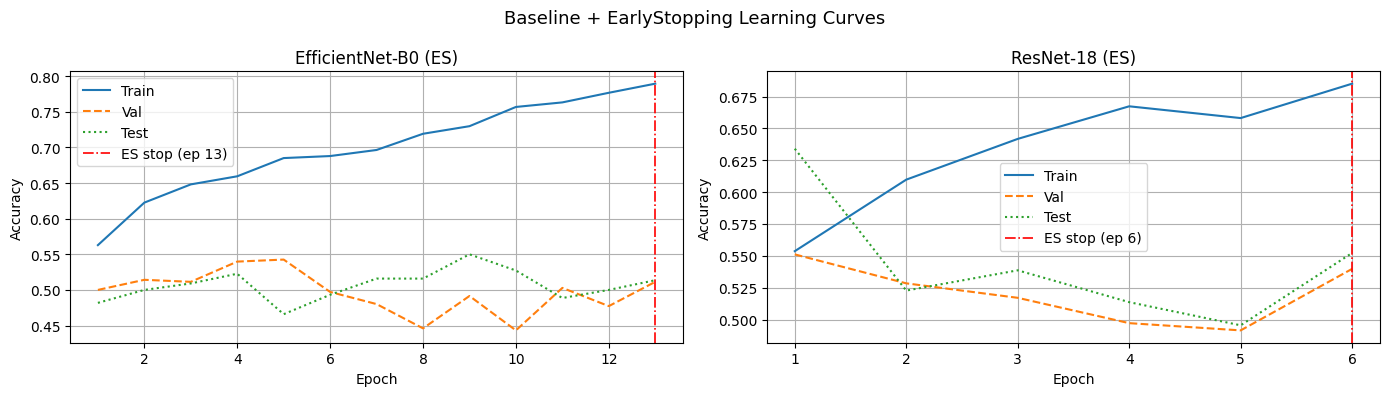

In [24]:
# EarlyStopping 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, name, tr, val, te, stop_ep in [
    (axes[0], 'EfficientNet-B0 (ES)', es_eff_tr, es_eff_val, es_eff_te, es_eff_stop),
    (axes[1], 'ResNet-18 (ES)',        es_res_tr, es_res_val, es_res_te, es_res_stop),
]:
    eps = range(1, len(tr) + 1)
    ax.plot(eps, tr,  label='Train')
    ax.plot(eps, val, label='Val',  linestyle='--')
    ax.plot(eps, te,  label='Test', linestyle=':')
    # EarlyStopping 종료 지점 표시
    ax.axvline(x=stop_ep, color='red', linestyle='-.', linewidth=1.2, label=f'ES stop (ep {stop_ep})')
    ax.set_title(name); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(True)

plt.suptitle('Baseline + EarlyStopping Learning Curves', fontsize=13)
plt.tight_layout()
plt.savefig('viz_earlystop_curves.png', dpi=150)
plt.show()


In [25]:
all_results = pd.concat([eff_results, res_results]).reset_index(drop=True)
print(all_results.to_string(index=False))

    backbone     lr  num_epochs optimizer  weight_decay  val_acc
efficientnet 0.0003          20      Adam         0.005   0.5881
efficientnet 0.0005          15      Adam         0.005   0.5511
efficientnet 0.0003          15      Adam         0.001   0.5426
efficientnet 0.0005          15      Adam         0.001   0.5312
efficientnet 0.0003          20      Adam         0.001   0.5312
efficientnet 0.0001          20      Adam         0.005   0.5170
efficientnet 0.0001          15      Adam         0.005   0.5085
efficientnet 0.0005          10      Adam         0.001   0.5057
efficientnet 0.0005          10      Adam         0.005   0.4943
efficientnet 0.0001          15      Adam         0.001   0.4261
    resnet18 0.0003          20      Adam         0.001   0.6278
    resnet18 0.0005          10      Adam         0.001   0.5966
    resnet18 0.0005          15      Adam         0.005   0.5938
    resnet18 0.0001          15      Adam         0.005   0.5881
    resnet18 0.0003      

# Part 6. 최적 파라미터로 최종 학습

In [26]:
def train_full(backbone, cfg, train_loader, val_loader, test_loader, device, extra_epochs=10):
    """best_state 로드 없이 처음부터 재학습 — epoch은 cfg + extra_epochs."""
    model = VideoEncoder(backbone=backbone).to(device)  # 처음부터
    criterion = nn.CrossEntropyLoss()
    wd = cfg.get('weight_decay', 0)
    optimizer = (
        optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=wd)
        if cfg['optimizer'] == 'Adam'
        else optim.SGD(model.parameters(), lr=cfg['lr'], momentum=0.9, weight_decay=wd)
    )
    # lr scheduler 추가
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cfg['num_epochs'] + extra_epochs
    )

    total_epochs = cfg['num_epochs'] + extra_epochs
    train_accs, val_accs, test_accs = [], [], []
    best_val, best_state = 0.0, None

    for ep in range(1, total_epochs + 1):
        _, tr_acc  = run_epoch(model, train_loader, criterion, optimizer, device, train=True)
        _, val_acc = run_epoch(model, val_loader,   criterion, None,      device, train=False)
        _, te_acc  = run_epoch(model, test_loader,  criterion, None,      device, train=False)
        scheduler.step()
        train_accs.append(tr_acc); val_accs.append(val_acc); test_accs.append(te_acc)
        print(f'  Epoch {ep}/{total_epochs}  train={tr_acc:.4f}  val={val_acc:.4f}  test={te_acc:.4f}')

        # val 기준 best 모델 저장
        if val_acc > best_val:
            best_val = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # best val 모델로 복원
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    return model, train_accs, val_accs, test_accs

In [27]:
print(f'=== EfficientNet-B0 최종 학습 ===')
print(f'config: {eff_best}')
eff_model, eff_tr_accs, eff_val_accs, eff_te_accs = train_full(
    'efficientnet', eff_best, train_loader, val_loader, test_loader, device
)

=== EfficientNet-B0 최종 학습 ===
config: {'backbone': 'efficientnet', 'lr': 0.0003, 'num_epochs': 20, 'optimizer': 'Adam', 'weight_decay': 0.005, 'val_acc': 0.5881}
  Epoch 1/30  train=0.5373  val=0.5398  test=0.4977
  Epoch 2/30  train=0.6290  val=0.5256  test=0.4977
  Epoch 3/30  train=0.6311  val=0.4290  test=0.4545
  Epoch 4/30  train=0.6603  val=0.5000  test=0.4932
  Epoch 5/30  train=0.6766  val=0.5199  test=0.4886


  Epoch 6/30  train=0.6851  val=0.5256  test=0.4636
  Epoch 7/30  train=0.6965  val=0.5114  test=0.4932
  Epoch 8/30  train=0.7207  val=0.5028  test=0.4864
  Epoch 9/30  train=0.7321  val=0.4943  test=0.5091
  Epoch 10/30  train=0.7299  val=0.5057  test=0.5068
  Epoch 11/30  train=0.7299  val=0.5057  test=0.4955
  Epoch 12/30  train=0.7569  val=0.5170  test=0.4659
  Epoch 13/30  train=0.7768  val=0.5170  test=0.5114
  Epoch 14/30  train=0.7768  val=0.5142  test=0.5341
  Epoch 15/30  train=0.7989  val=0.5057  test=0.5068
  Epoch 16/30  train=0.8202  val=0.5170  test=0.4955
  Epoch 17/30  train=0.8351  val=0.5142  test=0.4864
  Epoch 18/30  train=0.8273  val=0.5028  test=0.4955
  Epoch 19/30  train=0.8344  val=0.4830  test=0.5023
  Epoch 20/30  train=0.8692  val=0.5057  test=0.4955
  Epoch 21/30  train=0.8486  val=0.4915  test=0.4727
  Epoch 22/30  train=0.8714  val=0.4773  test=0.4727
  Epoch 23/30  train=0.8820  val=0.5057  test=0.4955
  Epoch 24/30  train=0.8820  val=0.5057  test=0.49

In [28]:
print(f'=== ResNet-18 최종 학습 ===')
print(f'config: {res_best}')
res_model, res_tr_accs, res_val_accs, res_te_accs = train_full(
    'resnet18', res_best, train_loader, val_loader, test_loader, device
)


=== ResNet-18 최종 학습 ===
config: {'backbone': 'resnet18', 'lr': 0.0003, 'num_epochs': 20, 'optimizer': 'Adam', 'weight_decay': 0.001, 'val_acc': 0.6278}
  Epoch 1/30  train=0.5544  val=0.4886  test=0.4977
  Epoch 2/30  train=0.5842  val=0.5369  test=0.5205
  Epoch 3/30  train=0.6127  val=0.5312  test=0.5273
  Epoch 4/30  train=0.6475  val=0.6364  test=0.5864
  Epoch 5/30  train=0.6510  val=0.5966  test=0.5932
  Epoch 6/30  train=0.6823  val=0.6080  test=0.5886
  Epoch 7/30  train=0.6702  val=0.5398  test=0.5409
  Epoch 8/30  train=0.6894  val=0.5881  test=0.5750
  Epoch 9/30  train=0.7164  val=0.6080  test=0.5932
  Epoch 10/30  train=0.7100  val=0.5455  test=0.5682
  Epoch 11/30  train=0.7413  val=0.5852  test=0.5841


  Epoch 12/30  train=0.7562  val=0.6080  test=0.6136
  Epoch 13/30  train=0.7484  val=0.6108  test=0.5841
  Epoch 14/30  train=0.7761  val=0.5540  test=0.5409
  Epoch 15/30  train=0.7683  val=0.5881  test=0.6023
  Epoch 16/30  train=0.8024  val=0.5455  test=0.5636
  Epoch 17/30  train=0.8173  val=0.5938  test=0.6114
  Epoch 18/30  train=0.8081  val=0.5909  test=0.5977
  Epoch 19/30  train=0.8415  val=0.5511  test=0.5614
  Epoch 20/30  train=0.8515  val=0.5483  test=0.5636
  Epoch 21/30  train=0.8600  val=0.5682  test=0.5659
  Epoch 22/30  train=0.8820  val=0.6051  test=0.5841
  Epoch 23/30  train=0.8927  val=0.6023  test=0.6000
  Epoch 24/30  train=0.9005  val=0.5852  test=0.5864
  Epoch 25/30  train=0.9161  val=0.5966  test=0.5977
  Epoch 26/30  train=0.9225  val=0.5966  test=0.5909
  Epoch 27/30  train=0.9225  val=0.5938  test=0.5932
  Epoch 28/30  train=0.9247  val=0.5966  test=0.5841
  Epoch 29/30  train=0.9282  val=0.5909  test=0.5795
  Epoch 30/30  train=0.9325  val=0.5994  test=

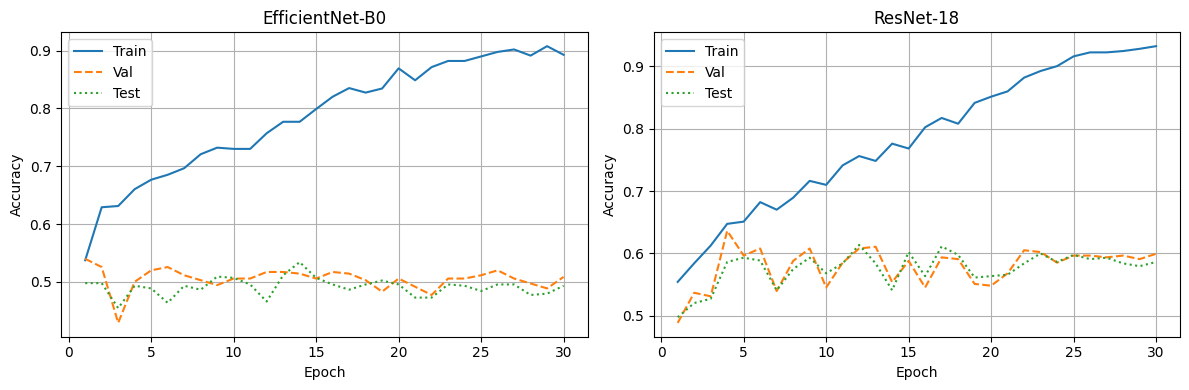

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name, tr, val, te in [
    (axes[0], 'EfficientNet-B0', eff_tr_accs, eff_val_accs, eff_te_accs),
    (axes[1], 'ResNet-18',       res_tr_accs, res_val_accs, res_te_accs),
]:
    eps = range(1, len(tr) + 1)
    ax.plot(eps, tr,  label='Train')
    ax.plot(eps, val, label='Val',  linestyle='--')
    ax.plot(eps, te,  label='Test', linestyle=':')
    ax.set_title(name); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig('viz_accuracy_curves.png', dpi=150)
plt.show()


In [30]:
label_names = ['Negative', 'Positive']

for name, model in [('EfficientNet-B0', eff_model), ('ResNet-18', res_model)]:
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for x, y in test_loader:
            out = model(x.to(device))
            preds.extend(out.argmax(1).cpu().tolist())
            targets.extend(y.tolist())
    print(f'=== {name} (test_acc={sum(p==t for p,t in zip(preds,targets))/len(targets):.4f}) ===')
    print(classification_report(targets, preds, target_names=label_names))

=== EfficientNet-B0 (test_acc=0.4977) ===
              precision    recall  f1-score   support

    Negative       0.51      0.37      0.43       224
    Positive       0.49      0.63      0.55       216

    accuracy                           0.50       440
   macro avg       0.50      0.50      0.49       440
weighted avg       0.50      0.50      0.49       440

=== ResNet-18 (test_acc=0.5864) ===
              precision    recall  f1-score   support

    Negative       0.63      0.46      0.53       224
    Positive       0.56      0.71      0.63       216

    accuracy                           0.59       440
   macro avg       0.59      0.59      0.58       440
weighted avg       0.59      0.59      0.58       440



# Part 7. 256-dim 피처 추출 (멀티모달 Fusion 준비)

`VideoEncoder.extract_features()` 로 256-dim 벡터를 추출한다.  
멀티모달 학습 시 이 벡터를 audio/text 피처와 concat하여 MLP에 입력한다.

```
video 256-dim ─┐
audio 256-dim ─┼─ concat(768) → MLP → 감성 분류
text  256-dim ─┘
```

선택된 모델: ResNet-18 (val_acc=0.6364  test_acc=0.6136)


feature extraction: 100%|██████████| 35/35 [00:01<00:00, 25.60it/s]


피처 shape: torch.Size([2199, 256])  →  (N, 256)
멀티모달 fusion 시 이 텐서를 audio/text 피처와 concat하세요.


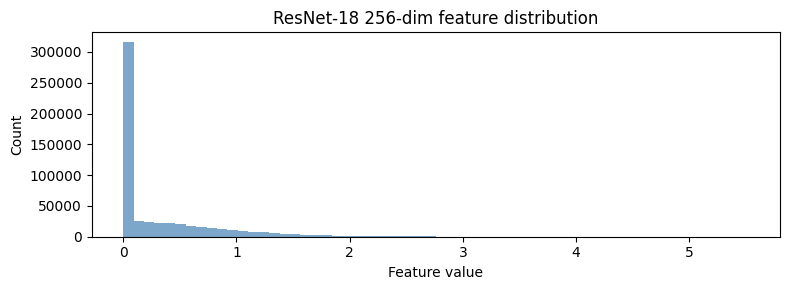

피처 저장: /data/news_group/newsgroup/code/AI/labeling/train/emotion/data/video_features_256.pkl


In [37]:
# [Fix 4] 마지막 epoch 대신 최고 val_acc 기준으로 모델 선택
if max(eff_val_accs) >= max(res_val_accs):
    best_model_name, best_model = 'EfficientNet-B0', eff_model
else:
    best_model_name, best_model = 'ResNet-18', res_model

final_val_acc  = max(eff_val_accs  if best_model_name == 'EfficientNet-B0' else res_val_accs)
final_test_acc = max(eff_te_accs   if best_model_name == 'EfficientNet-B0' else res_te_accs)
print(f'선택된 모델: {best_model_name} (val_acc={final_val_acc:.4f}  test_acc={final_test_acc:.4f})')

# 전체 데이터셋 256-dim 피처 추출
all_loader = DataLoader(
    ImageDataset(images, labels, test_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NW, persistent_workers=False
)
video_feats, video_labels = best_model.extract_features(all_loader, device)

print(f'\n피처 shape: {video_feats.shape}  →  (N, {FEATURE_DIM})')
print('멀티모달 fusion 시 이 텐서를 audio/text 피처와 concat하세요.')

# 피처 분포 시각화
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(video_feats.numpy().flatten(), bins=60, color='steelblue', alpha=0.7)
ax.set_title(f'{best_model_name} 256-dim feature distribution')
ax.set_xlabel('Feature value'); ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('viz_feature_dist.png', dpi=150)
plt.show()

# 피클로 저장 (멀티모달 학습 시 재사용)
feat_save_path = os.path.join(ROOT_PATH, 'video_features_256.pkl')
with open(feat_save_path, 'wb') as f:
    pickle.dump({'features': video_feats, 'labels': video_labels}, f)
print(f'피처 저장: {feat_save_path}')
